# 02 — Initial Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned and transformed World Bank indicator datasets.

**Inputs:** Cleaned CSVs from `01_ingestion_and_imputation/`  
**Outputs:** Distribution plots, missing-value heatmaps, correlation heatmaps saved to this folder

**Datasets:**
- Economic Indicators
- Environmental Indicators
- Public Debt Indicators
- Social Indicators
- Statistical Indicators

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load Cleaned Datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load the combined imputed file
DATA_DIR = '../01_ingestion_and_imputation/'
combined_path = os.path.join(DATA_DIR, 'imputed_data_less_than_70_missing.csv')
df_all = pd.read_csv(combined_path, low_memory=False)
print(f'Loaded combined dataset: {df_all.shape}')
print(f'Columns: {df_all.columns.tolist()[:10]}')

# Identify domain split column
# Try 'Source' column first (QPSD / WDI / SPI), else use Series Name keywords
if 'Source' in df_all.columns:
    domain_col = 'Source'
    dfs = {
        'QPSD (Public Debt)':   df_all[df_all[domain_col] == 'QPSD'],
        'WDI (Development)':    df_all[df_all[domain_col] == 'WDI'],
        'SPI (Statistical)':    df_all[df_all[domain_col] == 'SPI'],
    }
else:
    # Fallback: treat whole dataset as one domain
    dfs = {'All Indicators': df_all}

for name, df in dfs.items():
    print(f'  {name}: {df.shape}')


Loaded combined dataset: (874836, 9)
Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', 'Quarter', 'Value', 'Year', 'Source', 'Indicator Category']
  QPSD (Public Debt): (514368, 9)
  WDI (Development): (344052, 9)
  SPI (Statistical): (16416, 9)


## 2. Missing Value Analysis

In [3]:
# Missing value percentage summary
missing_pct = {
    name: round((df.isnull().sum().sum() / df.size) * 100, 2)
    for name, df in dfs.items()
}
missing_df = pd.DataFrame(list(missing_pct.items()), columns=["Dataset", "Missing %"])
print(missing_df.to_string(index=False))

           Dataset  Missing %
QPSD (Public Debt)       0.00
 WDI (Development)      12.64
 SPI (Statistical)      11.11


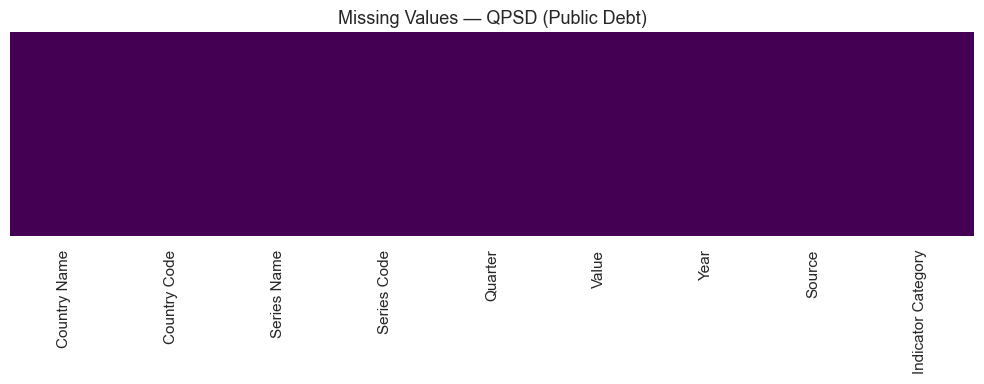

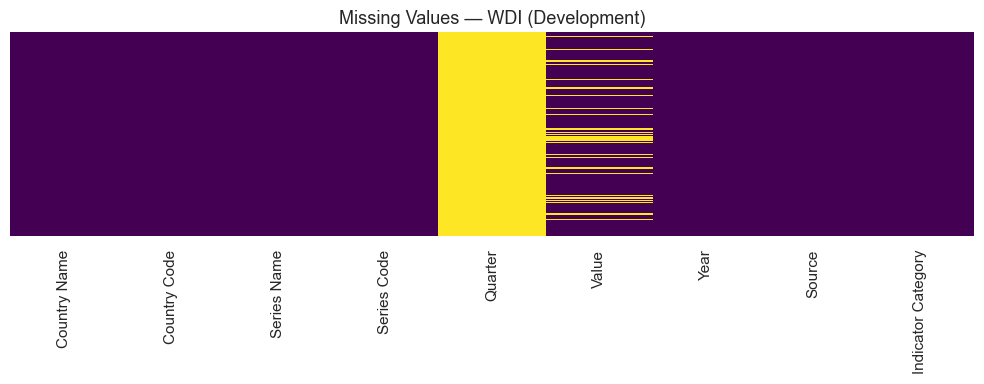

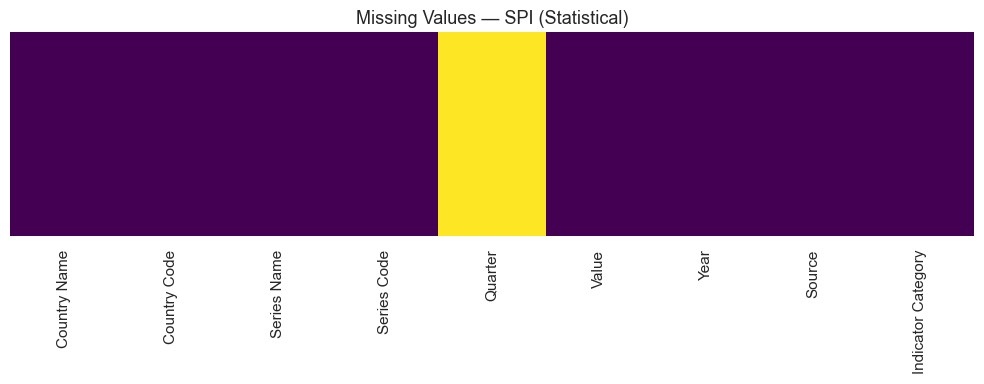

In [4]:
# Missing value heatmaps per dataset
for name, df in dfs.items():
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
    ax.set_title(f'Missing Values — {name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'missing_values_{name}.png', bbox_inches='tight')
    plt.show()

## 3. Descriptive Statistics

In [5]:
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"Descriptive Statistics — {name}")
    print('='*60)
    display(df.describe())


Descriptive Statistics — QPSD (Public Debt)


,Value,Year
count,5.143680e+05,514368.000000
mean,2.029577e+13,2022.000000
std,2.136792e+14,0.816497
min,0.000000e+00,2021.000000
25%,5.773179e+00,2021.000000
50%,3.334486e+09,2022.000000
75%,2.257081e+11,2023.000000
max,1.579202e+16,2023.000000



Descriptive Statistics — WDI (Development)


,Value,Year
count,2.968560e+05,344052.000000
mean,4.774979e+12,2022.000000
std,1.999230e+14,0.816498
min,-5.382066e+14,2021.000000
25%,5.587116e+00,2021.000000
50%,4.044571e+01,2022.000000
75%,1.514166e+04,2023.000000
max,2.089238e+16,2023.000000



Descriptive Statistics — SPI (Statistical)


,Value,Year
count,16416.000000,16416.000000
mean,7.631744,2022.000000
std,23.007947,0.816521
min,0.000000,2021.000000
25%,0.750000,2021.000000
50%,1.000000,2022.000000
75%,1.000000,2023.000000
max,100.000000,2023.000000


## 4. Value Distributions (Histograms)

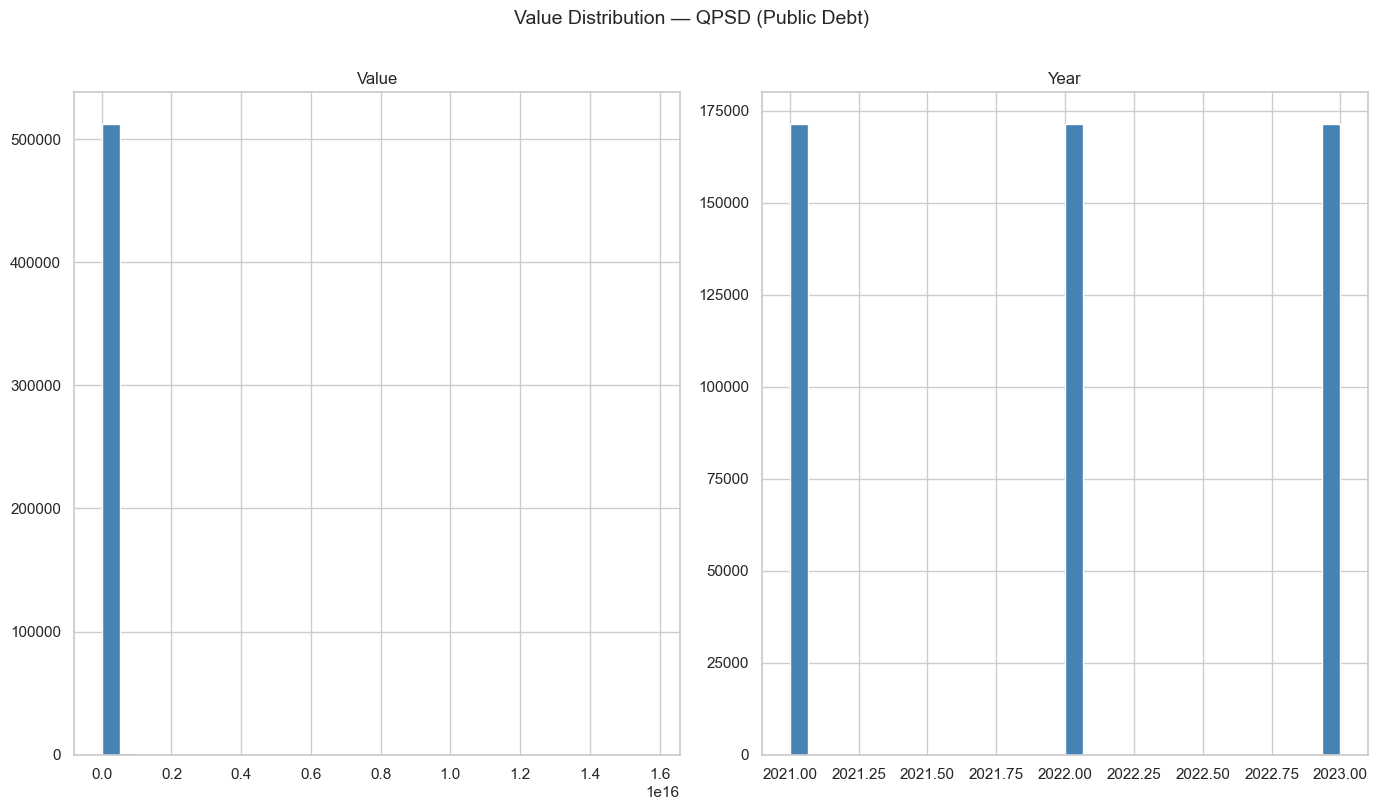

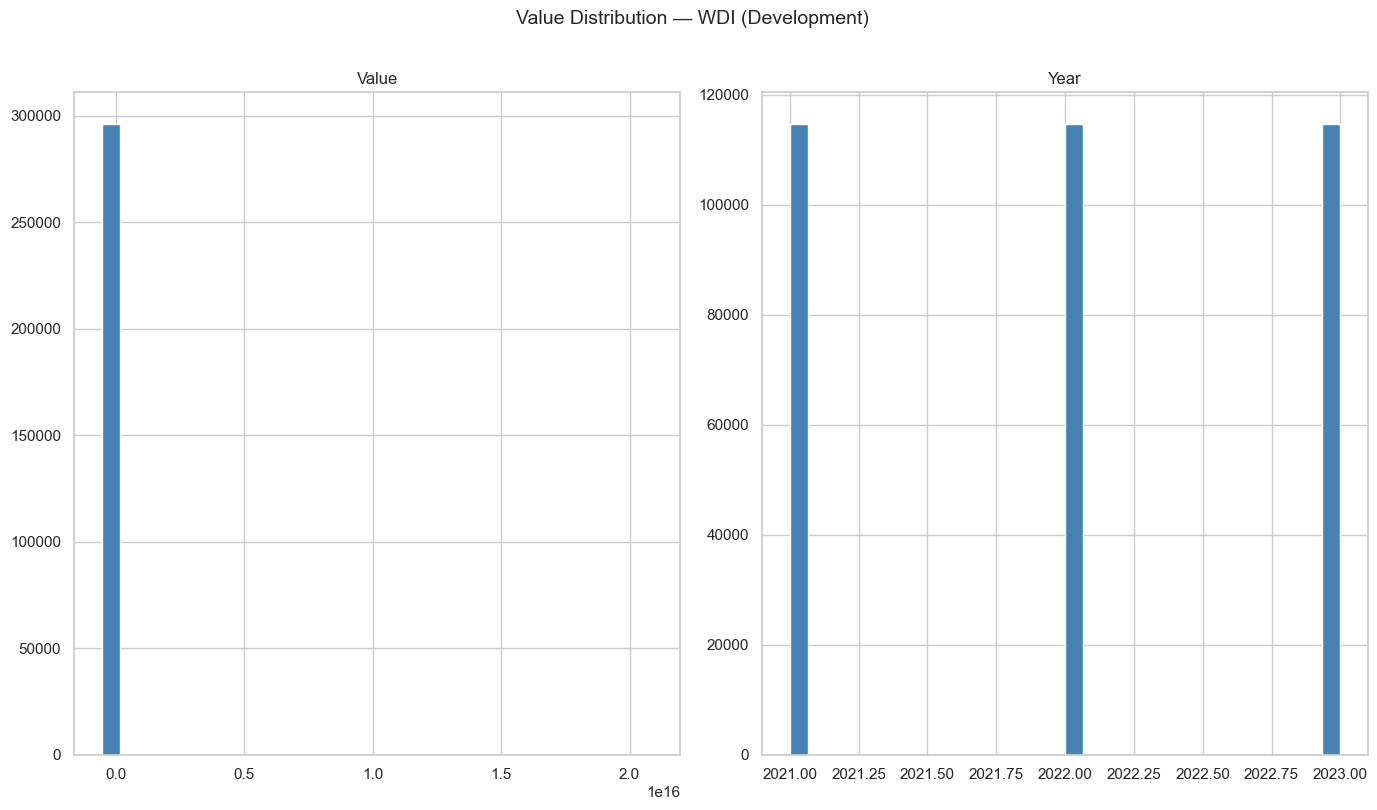

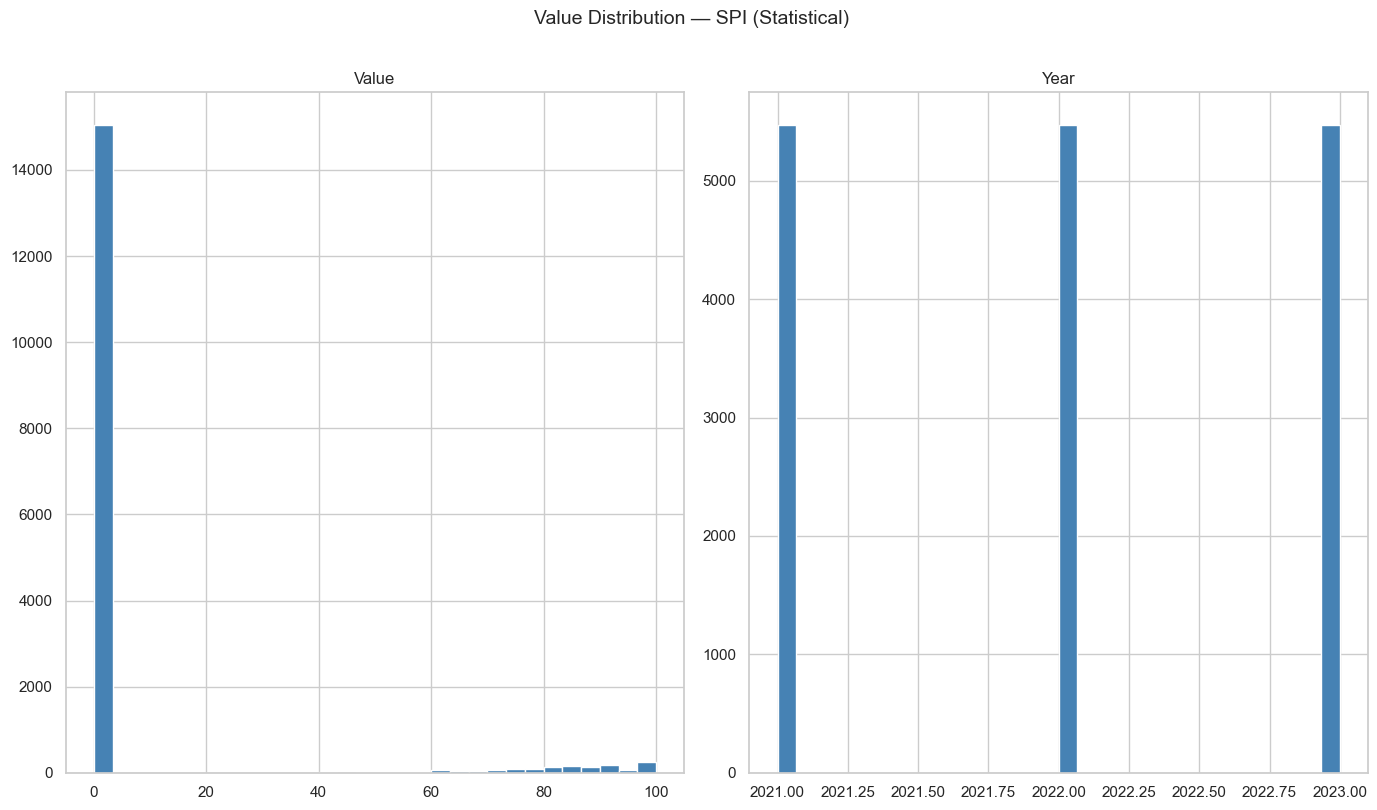

In [6]:
for name, df in dfs.items():
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        continue
    df[numeric_cols].hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
    plt.suptitle(f'Value Distribution — {name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'distribution_{name}.png', bbox_inches='tight')
    plt.show()

## 5. Outlier Detection (Boxplots)

/var/folders/1z/3vxh56rd01976z5trfcdk37h0000gn/T/ipykernel_20450/2844670823.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


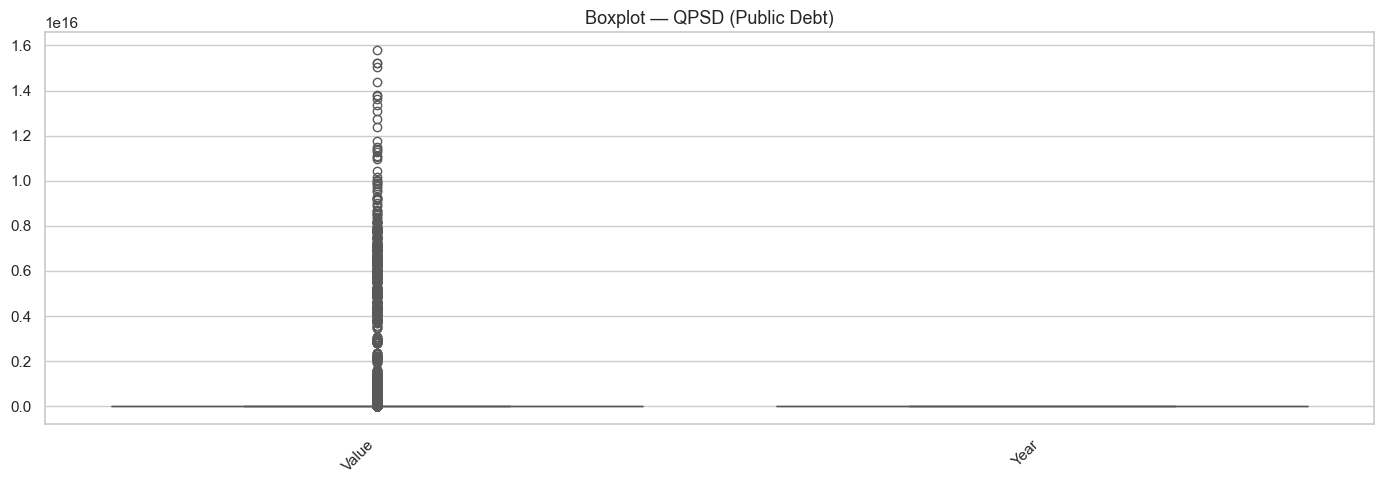

/var/folders/1z/3vxh56rd01976z5trfcdk37h0000gn/T/ipykernel_20450/2844670823.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


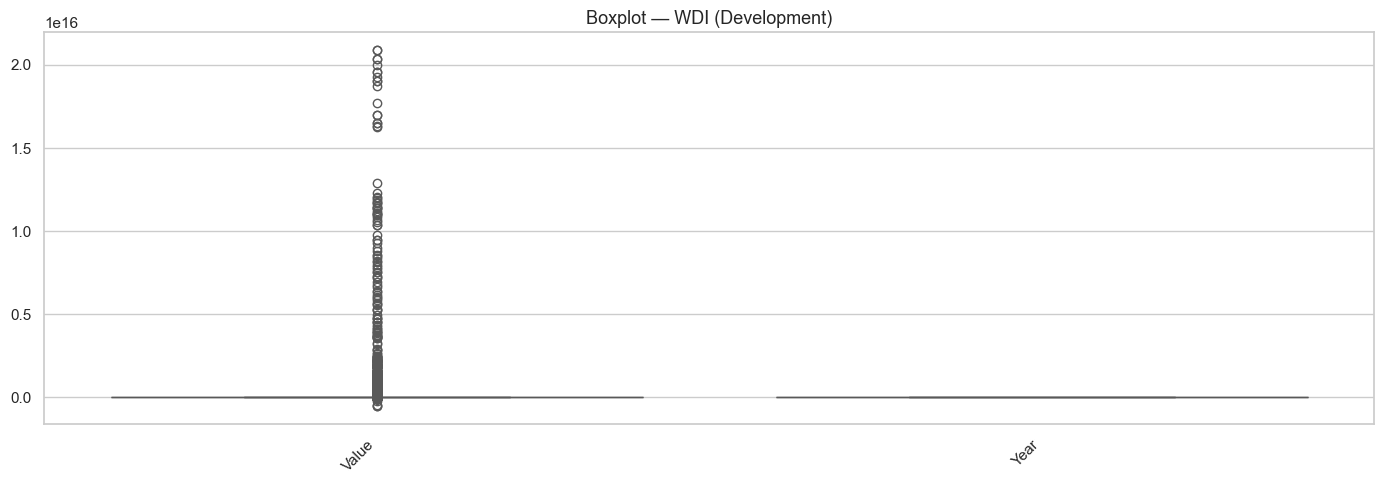

/var/folders/1z/3vxh56rd01976z5trfcdk37h0000gn/T/ipykernel_20450/2844670823.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


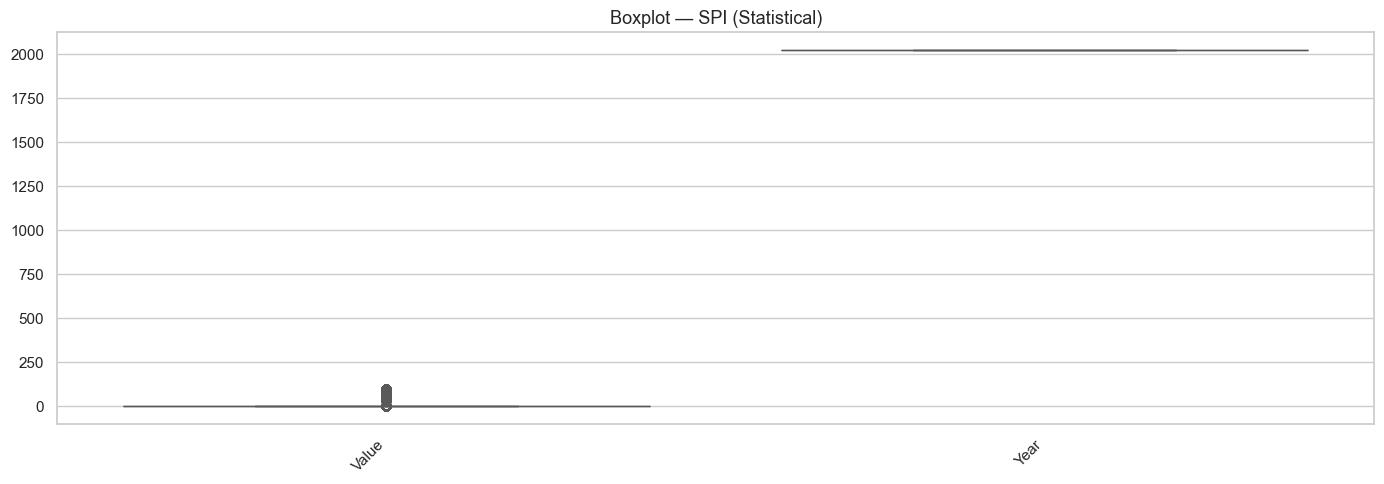

In [7]:
for name, df in dfs.items():
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        continue
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=df[numeric_cols], ax=ax, palette='Set2')
    ax.set_title(f'Boxplot — {name}', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'boxplot_{name}.png', bbox_inches='tight')
    plt.show()

## 6. Correlation Heatmaps

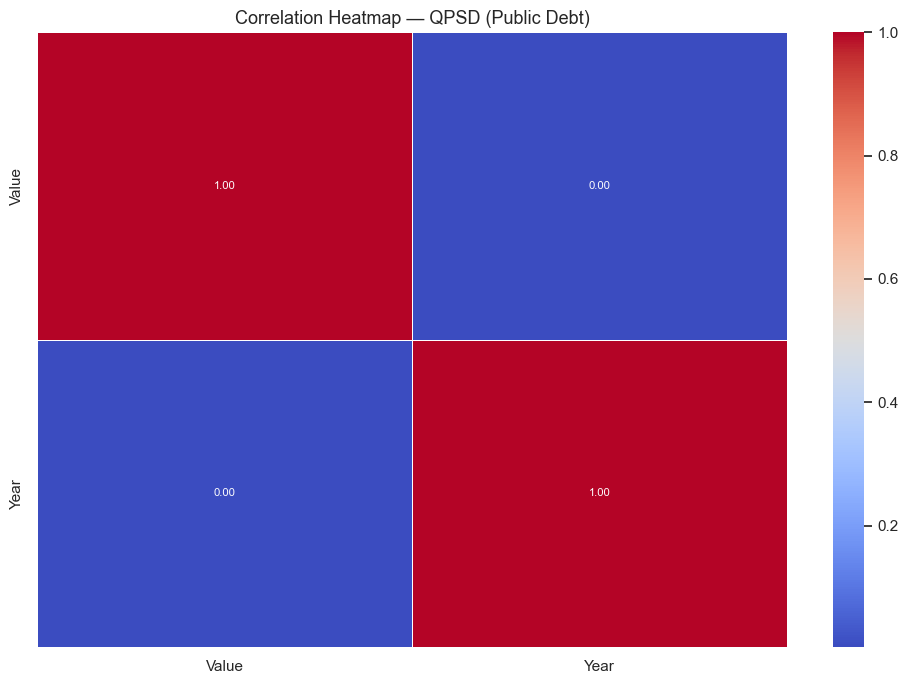

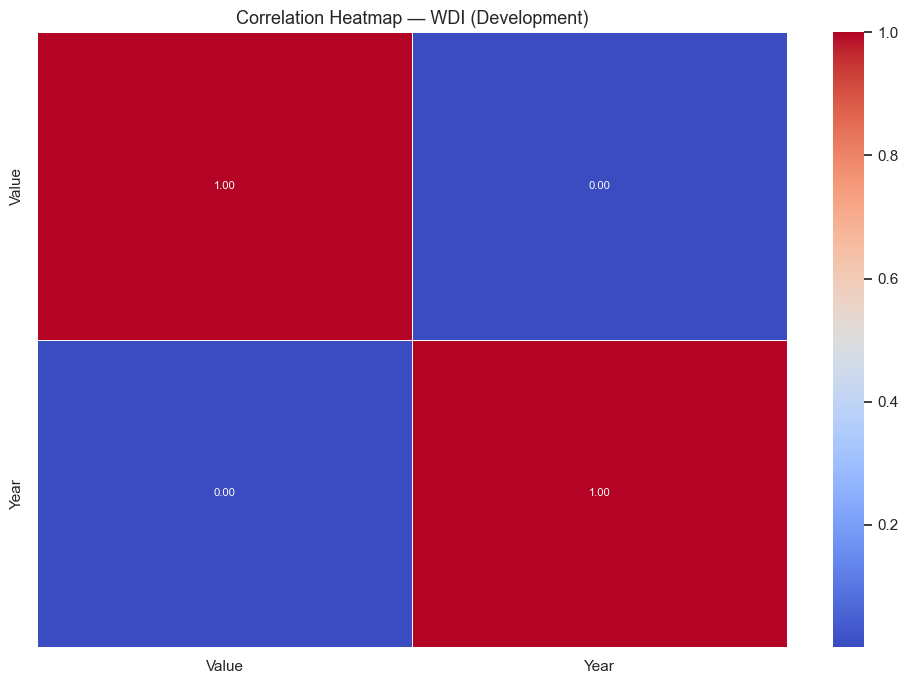

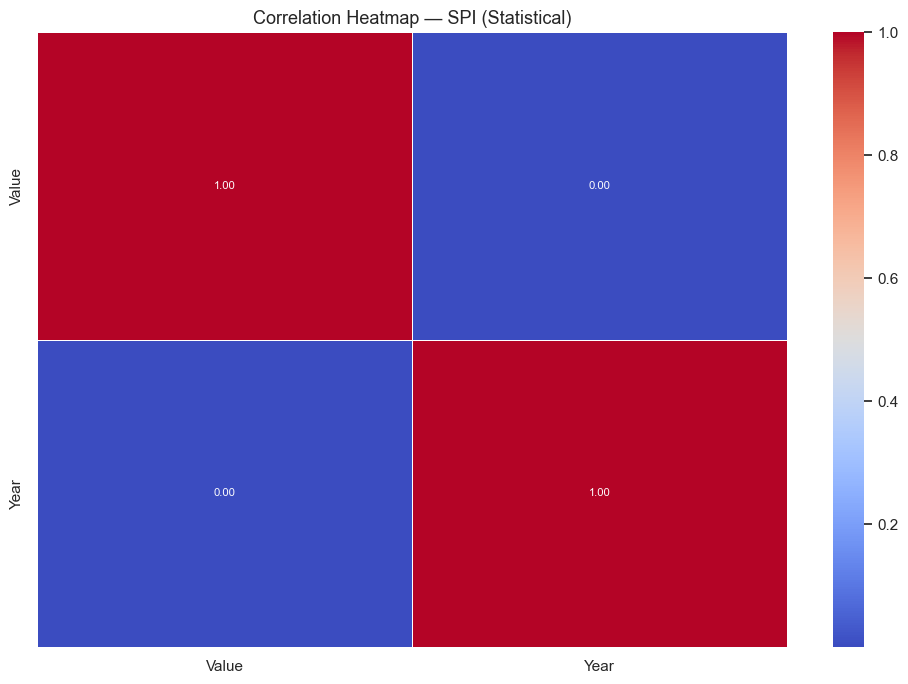

In [8]:
for name, df in dfs.items():
    numeric_df = df.select_dtypes(include='number')
    if numeric_df.shape[1] < 2:
        continue
    corr = numeric_df.corr()
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='coolwarm',
        linewidths=0.5, ax=ax, annot_kws={'size': 8}
    )
    ax.set_title(f'Correlation Heatmap — {name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'correlation_{name}.png', bbox_inches='tight')
    plt.show()

## 7. Regional and Indicator Coverage

The PNGs `regional_coverage.png` and `regional_indicator_coverage.png` in this folder were generated separately using the `pycountry` library to map `country_code` → region, then aggregating indicator counts per region.


regional_coverage.png


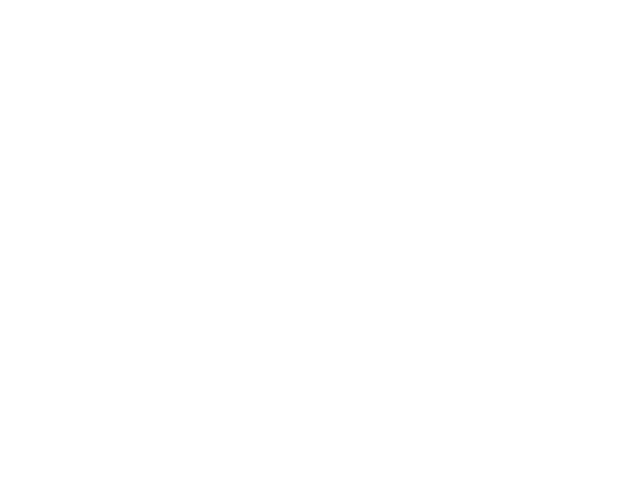


regional_indicator_coverage.png


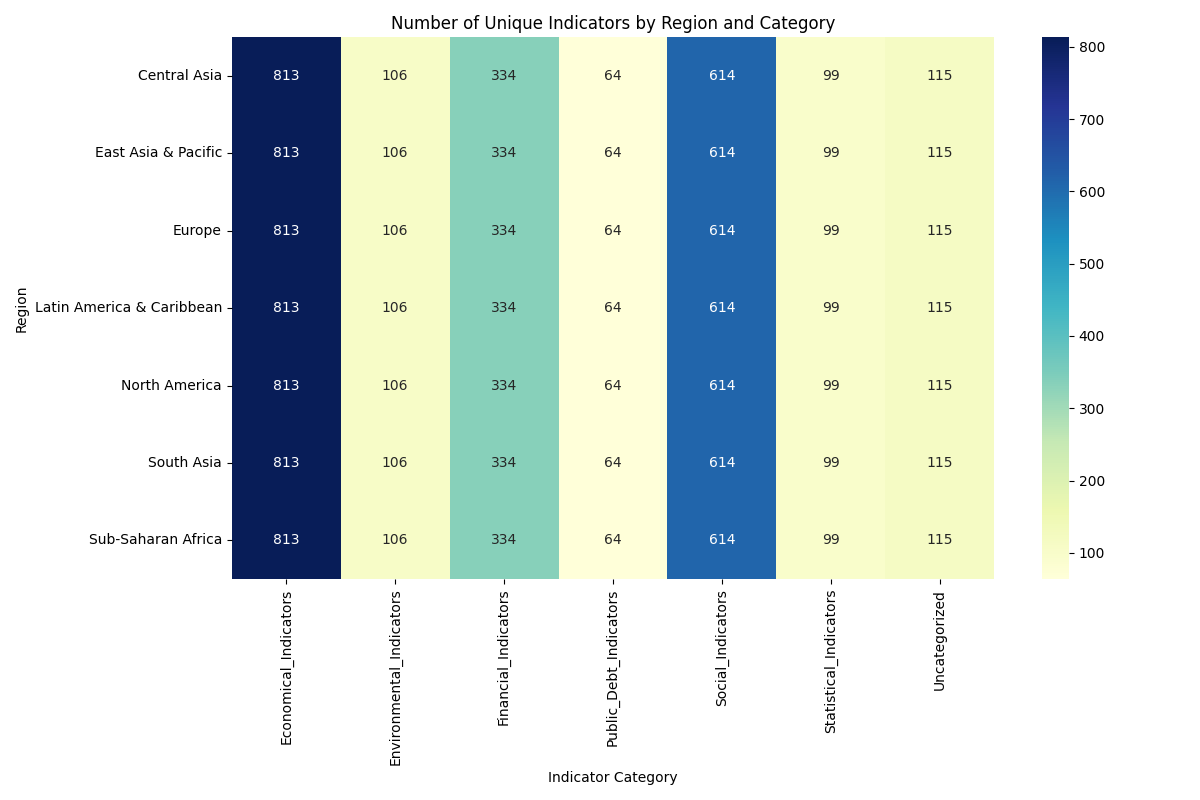


economic_values_distribution.png


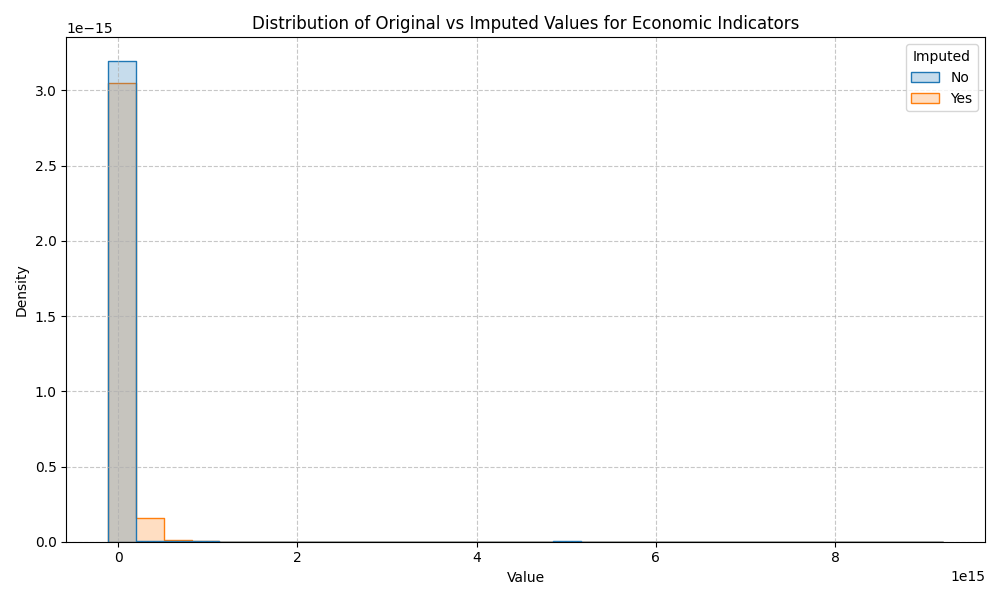

In [9]:
# Display the pre-generated regional coverage plots
from IPython.display import Image, display as ipy_display

for img_path in ['regional_coverage.png', 'regional_indicator_coverage.png', 'economic_values_distribution.png']:
    if os.path.exists(img_path):
        print(f"\n{img_path}")
        ipy_display(Image(img_path))

## Summary

| Finding | Detail |
|---------|--------|
| Highest missingness | Public Debt Indicators (~quarterly data with sparse coverage) |
| Strongest correlations | GDP-related economic indicators cluster together |
| Outlier risk | Financial indicators show heavy right skew |
| Country coverage | 217 countries across 7 World Bank regions |

All plots saved as PNGs in this directory for use in the final report.